In [20]:
# =============================================================================
# CELL 1: Import Libraries
# =============================================================================

import os
import json
import pickle
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

# Set seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Random seed: {RANDOM_SEED}")

Libraries imported successfully
TensorFlow version: 2.20.0
OpenCV version: 4.12.0
Random seed: 42


In [21]:
# =============================================================================
# CELL 2: Configuration
# =============================================================================

# Robust base dir handling (works whether notebook is run from project root or from notebooks/)
CWD = Path.cwd()
BASE_DIR = str(CWD.parent if CWD.name == "notebooks" else CWD)

# Try common dataset layouts (project-local or sibling dataset folder)
BASE_PATH = Path(BASE_DIR)
candidates = [
    BASE_PATH,                         # BASE_DIR/train and BASE_DIR/test
    BASE_PATH / "dataset",             # BASE_DIR/dataset/train and BASE_DIR/dataset/test
    BASE_PATH.parent / "dataset",      # sibling dataset folder
    BASE_PATH.parent,                   # parent/train and parent/test (last resort)
 ]
DATASET_PATH = None
for cand in candidates:
    if (cand / "train").exists() and (cand / "test").exists():
        DATASET_PATH = cand
        break

if DATASET_PATH is None:
    tried = "\n  - " + "\n  - ".join(str(c) for c in candidates)
    raise FileNotFoundError(
        "Could not find dataset folders 'train' and 'test'. Tried:" + tried +
        "\n\nFix options:"
        "\n  1) Put your data under <project>/train and <project>/test"
        "\n  2) Or under <project>/dataset/train and <project>/dataset/test"
        "\n  3) Or update TRAIN_DIR/TEST_DIR to your actual paths."
    )

TRAIN_DIR = str(DATASET_PATH / "train")
TEST_DIR = str(DATASET_PATH / "test")

# Output directory for preprocessed data
PREPROCESSED_DIR = os.path.join(BASE_DIR, 'preprocessed')
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

# Character image dimensions
CHAR_H = 64  # Height of normalized character
CHAR_W = 64  # Width of normalized character
NUM_CHANNELS = 3  # RGB (better for augmentation)

# Segmentation parameters
MIN_CHAR_WIDTH = 6   # Minimum character width in pixels
MIN_LINE_HEIGHT = 6  # Minimum line height in pixels
MIN_WORD_SIZE = 8    # Minimum word dimension

# Data augmentation - split image into vertical strips
NUM_VERTICAL_SPLITS = 3  # Split each image into 3 parts
AUGMENT_EACH_SPLIT = True  # Create augmented version of each split

print("CONFIGURATION")
print("=" * 60)
print(f"Current working directory: {os.getcwd()}")
print(f"Base directory: {BASE_DIR}")
print(f"Dataset directory: {str(DATASET_PATH)}")
print(f"Train directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")
print(f"Preprocessed output: {PREPROCESSED_DIR}")
print(f"\nCharacter size: {CHAR_H}×{CHAR_W}×{NUM_CHANNELS}")
print(f"Min char width: {MIN_CHAR_WIDTH}px")
print(f"Vertical splits per image: {NUM_VERTICAL_SPLITS}")
print(f"Augment each split: {AUGMENT_EACH_SPLIT}")

CONFIGURATION
Current working directory: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\notebooks
Base directory: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition
Dataset directory: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition
Train directory: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\train
Test directory: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\test
Preprocessed output: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\preprocessed

Character size: 64×64×3
Min char width: 6px
Vertical splits per image: 3
Augment each split: True


In [22]:
# =============================================================================
# CELL 3: Verify Dataset Structure
# =============================================================================

def list_images(folder):
    """List all image files in a folder recursively."""
    p = Path(folder)
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")
    return sorted([str(fp) for fp in p.rglob("*") if fp.suffix.lower() in exts])

def label_from_filename(filepath):
    """Extract writer label from filename (first 2 characters)."""
    return Path(filepath).name[:2]

# List images
train_files = list_images(TRAIN_DIR)
test_files = list_images(TEST_DIR)

print("DATASET VERIFICATION")
print("=" * 60)
print(f"Training images found: {len(train_files)}")
print(f"Test images found: {len(test_files)}")

# Extract unique labels
train_labels = sorted({label_from_filename(f) for f in train_files})
test_labels = sorted({label_from_filename(f) for f in test_files})

print(f"\nUnique writers in train: {len(train_labels)}")
print(f"Unique writers in test: {len(test_labels)}")

# Check overlap
common_labels = set(train_labels) & set(test_labels)
print(f"Common writers (train & test): {len(common_labels)}")

# Display sample filenames
print(f"\nSample train files:")
for f in train_files[:3]:
    print(f"  {os.path.basename(f)} → Writer: {label_from_filename(f)}")

print(f"\nSample test files:")
for f in test_files[:3]:
    print(f"  {os.path.basename(f)} → Writer: {label_from_filename(f)}")

DATASET VERIFICATION
Training images found: 70
Test images found: 140

Unique writers in train: 70
Unique writers in test: 70
Common writers (train & test): 70

Sample train files:
  01_1_631.png → Writer: 01
  02_1_632.png → Writer: 02
  03_1_633.png → Writer: 03

Sample test files:
  01_2_281.png → Writer: 01
  01_2_491.png → Writer: 01
  02_2_352.png → Writer: 02


In [23]:
# =============================================================================
# CELL 4: Utility Functions
# =============================================================================

def to_grayscale(img):
    """Convert image to grayscale if needed."""
    if img is None:
        return None
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def resize_and_normalize_char(ch_img, target_h=CHAR_H, target_w=CHAR_W):
    """
    Resize character image while preserving aspect ratio,
    center it on a white background, and normalize to [0, 1].
    
    Returns: (target_h, target_w, 3) float32 array in [0, 1]
    """
    # Convert to RGB if grayscale
    if len(ch_img.shape) == 2:
        ch = cv2.cvtColor(ch_img, cv2.COLOR_GRAY2RGB)
    else:
        ch = ch_img.copy()
    
    h, w = ch.shape[:2]
    
    # Calculate scale to fit within target dimensions
    scale = min(target_w / max(1, w), target_h / max(1, h))
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    
    # Resize
    resized = cv2.resize(ch, (nw, nh), interpolation=cv2.INTER_AREA)
    
    # Create white background and center the character
    pad_left = (target_w - nw) // 2
    pad_top = (target_h - nh) // 2
    padded = 255 * np.ones((target_h, target_w, 3), dtype=np.uint8)
    padded[pad_top:pad_top+nh, pad_left:pad_left+nw, :] = resized
    
    # Normalize to [0, 1]
    return padded.astype(np.float32) / 255.0

print("✓ Utility functions defined")

✓ Utility functions defined


In [24]:
# =============================================================================
# CELL 5: Line Segmentation
# =============================================================================

def segment_lines(gray):
    """
    Segment a grayscale image into individual text lines.
    Uses horizontal projection profile to find line boundaries.
    
    Args:
        gray: Grayscale image (H, W)
    
    Returns:
        List of (y_start, y_end) tuples for each line
    """
    h = gray.shape[0]
    
    # Binarize using Otsu's threshold
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Morphological closing to connect broken strokes
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
    closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Compute horizontal projection (sum of pixels per row)
    proj = np.sum(closed, axis=1)
    
    if proj.max() == 0:
        return [(0, h)]  # Return entire image if no content detected
    
    # Threshold for detecting text rows
    thresh = max(1, int(0.03 * proj.max()))
    
    # Find line boundaries
    lines = []
    in_line = False
    start = 0
    
    for y, v in enumerate(proj):
        if v > thresh and not in_line:
            in_line = True
            start = y
        elif v <= thresh and in_line:
            end = y
            in_line = False
            if end - start >= MIN_LINE_HEIGHT:
                # Add small padding
                lines.append((max(0, start - 2), min(h, end + 2)))
    
    # Handle case where line extends to bottom
    if in_line:
        lines.append((start, h))
    
    return lines if lines else [(0, h)]

print("✓ Line segmentation function defined")

✓ Line segmentation function defined


In [25]:
# =============================================================================
# CELL 6: Word Segmentation
# =============================================================================

def segment_words_from_line(line_img):
    """
    Segment a text line image into individual words.
    Uses morphological dilation to connect characters, then finds contours.
    
    Args:
        line_img: Color or grayscale line image
    
    Returns:
        List of word images (cropped regions)
    """
    gray = to_grayscale(line_img)
    
    # Binarize
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Dilate horizontally to connect characters within words
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    dilated = cv2.dilate(th, kernel, iterations=1)
    
    # Find contours (each contour should be a word)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Extract bounding boxes
    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < MIN_WORD_SIZE or h < MIN_WORD_SIZE:
            continue
        bboxes.append((x, y, w, h))
    
    # Sort by x-coordinate (left to right)
    bboxes = sorted(bboxes, key=lambda b: b[0])
    
    # Extract word images
    words = [line_img[y:y+h, x:x+w] for (x, y, w, h) in bboxes]
    
    return words if words else [line_img]  # Return entire line if no words found

print("✓ Word segmentation function defined")

✓ Word segmentation function defined


In [26]:
# =============================================================================
# CELL 7: Character Segmentation
# =============================================================================

def segment_chars_from_word(word_img, min_char_width=MIN_CHAR_WIDTH):
    """
    Segment a word image into individual characters.
    Uses vertical projection profile to find character boundaries.
    
    Args:
        word_img: Color or grayscale word image
        min_char_width: Minimum width for a valid character
    
    Returns:
        List of character images (cropped regions)
    """
    gray = to_grayscale(word_img)
    
    # Binarize
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Compute vertical projection (sum of pixels per column)
    cols = np.sum(th, axis=0)
    
    if cols.max() == 0:
        return []  # Empty word
    
    # Threshold for detecting character columns
    thresh = max(1, int(0.05 * cols.max()))
    separators = cols <= thresh  # True where there's no ink (separator)
    
    # Find character boundaries
    chars = []
    in_char = False
    start = 0
    
    for i, is_sep in enumerate(separators):
        if not is_sep and not in_char:
            in_char = True
            start = i
        elif is_sep and in_char:
            end = i
            in_char = False
            if end - start >= min_char_width:
                chars.append(word_img[:, start:end])
    
    # Handle case where character extends to right edge
    if in_char:
        end = len(separators)
        if end - start >= min_char_width:
            chars.append(word_img[:, start:end])
    
    return chars

print("✓ Character segmentation function defined")

✓ Character segmentation function defined


In [27]:
# =============================================================================
# CELL 8: Data Augmentation (Pre-Segmentation)
# =============================================================================

# Strong augmentation applied BEFORE segmentation
# This creates realistic variations of the handwriting
augmentation_pipeline = tf.keras.Sequential([
    layers.RandomRotation(0.15),           # ±15% rotation (realistic slant variation)
    layers.RandomTranslation(0.08, 0.08),  # ±8% translation
    layers.RandomZoom(0.10, 0.10),         # ±10% zoom
    layers.RandomContrast(0.15),           # Contrast variation
], name="pre_segmentation_augmentation")

@tf.function
def _augment_tensor(x):
    """Apply augmentation to a batch of images."""
    return augmentation_pipeline(x, training=True)

def augment_image_numpy(img_uint8):
    """
    Apply augmentation to a uint8 image.
    
    Args:
        img_uint8: (H, W, C) uint8 image
    
    Returns:
        (H, W, C) uint8 augmented image
    """
    # Convert to float [0, 1]
    img = img_uint8.astype(np.float32) / 255.0
    
    # Add batch dimension and apply augmentation
    t = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
    aug = _augment_tensor(t)
    
    # Convert back to uint8
    aug_np = aug[0].numpy()
    aug_uint8 = np.clip(aug_np * 255.0, 0, 255).astype(np.uint8)
    
    return aug_uint8

print("✓ Data augmentation pipeline defined")
print("\nAugmentation parameters (applied before segmentation):")
print("  - Rotation: ±15%")
print("  - Translation: ±8%")
print("  - Zoom: ±10%")
print("  - Contrast: ±15%")

✓ Data augmentation pipeline defined

Augmentation parameters (applied before segmentation):
  - Rotation: ±15%
  - Translation: ±8%
  - Zoom: ±10%
  - Contrast: ±15%


Visualizing segmentation pipeline on sample image...


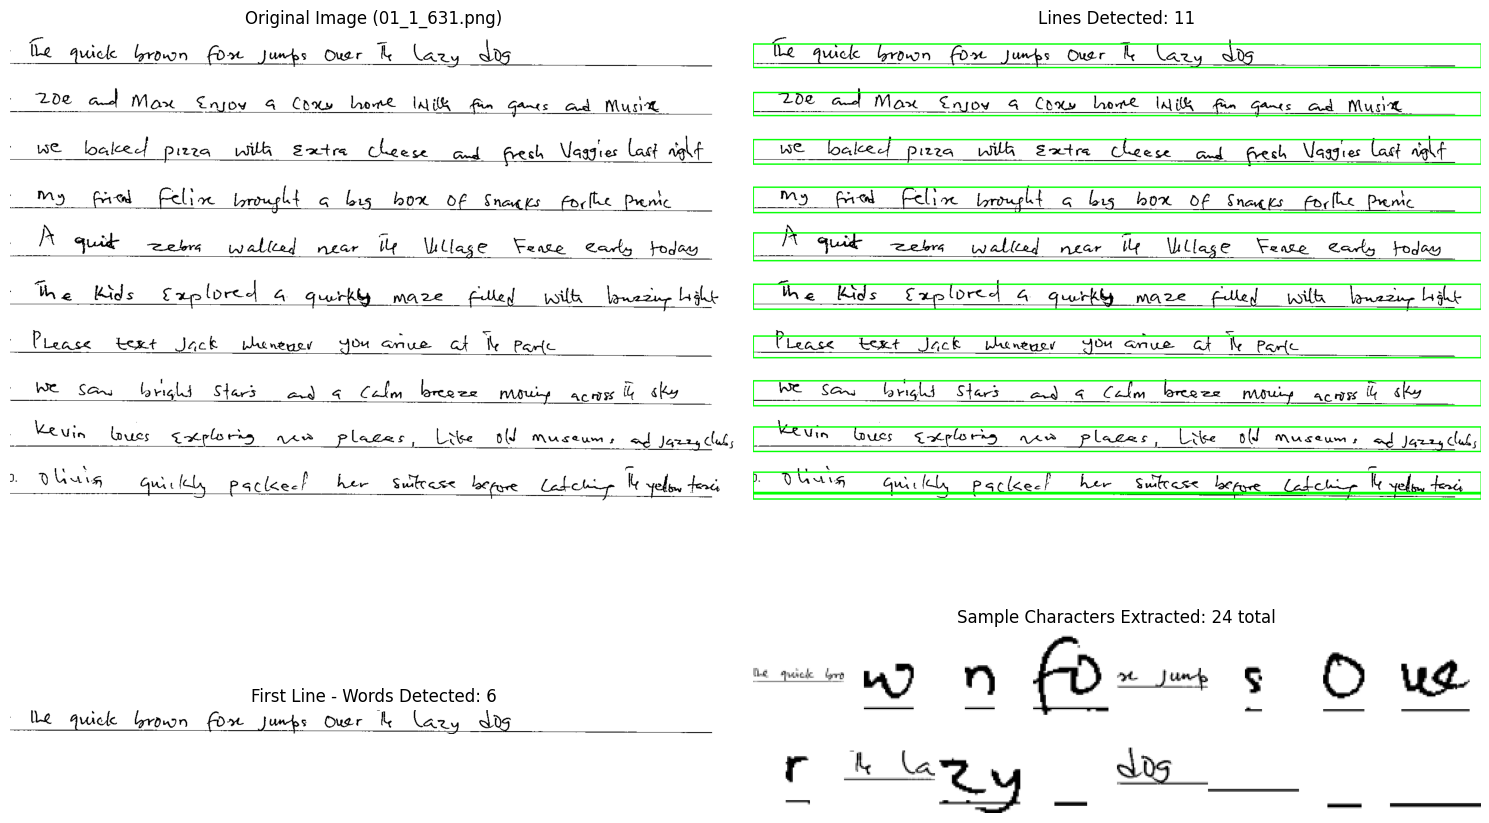

In [28]:
# =============================================================================
# CELL 9: Visualize Segmentation Pipeline
# =============================================================================

def visualize_segmentation(img_path):
    """Visualize the full segmentation pipeline on a sample image."""
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load: {img_path}")
        return
    
    gray = to_grayscale(img)
    
    # Segment lines
    lines = segment_lines(gray)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title(f"Original Image ({os.path.basename(img_path)})")
    axes[0, 0].axis('off')
    
    # Image with line boundaries
    img_lines = img.copy()
    for y1, y2 in lines:
        cv2.rectangle(img_lines, (0, y1), (img.shape[1], y2), (0, 255, 0), 2)
    axes[0, 1].imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title(f"Lines Detected: {len(lines)}")
    axes[0, 1].axis('off')
    
    # Extract and show characters from first line
    if lines:
        y1, y2 = lines[0]
        line_img = img[y1:y2, :]
        words = segment_words_from_line(line_img)
        
        # Show line with word boxes
        line_viz = line_img.copy()
        axes[1, 0].imshow(cv2.cvtColor(line_viz, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title(f"First Line - Words Detected: {len(words)}")
        axes[1, 0].axis('off')
        
        # Extract characters from all words
        all_chars = []
        for word in words:
            chars = segment_chars_from_word(word)
            all_chars.extend(chars)
        
        # Show sample characters
        if all_chars:
            n_show = min(16, len(all_chars))
            char_grid = np.ones((CHAR_H * 2, CHAR_W * 8, 3), dtype=np.float32)
            for i in range(n_show):
                ch_norm = resize_and_normalize_char(all_chars[i])
                row, col = i // 8, i % 8
                char_grid[row*CHAR_H:(row+1)*CHAR_H, col*CHAR_W:(col+1)*CHAR_W, :] = ch_norm
            
            axes[1, 1].imshow(char_grid)
            axes[1, 1].set_title(f"Sample Characters Extracted: {len(all_chars)} total")
            axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize on a sample image
if train_files:
    print("Visualizing segmentation pipeline on sample image...")
    visualize_segmentation(train_files[0])

In [29]:
# =============================================================================
# CELL 10: Full Character Extraction Pipeline
# =============================================================================

def extract_characters_from_image(img, apply_augmentation=False):
    """
    Extract all characters from an image using the segmentation pipeline.
    
    Args:
        img: Color image (H, W, 3) uint8
        apply_augmentation: Whether to also return augmented versions
    
    Returns:
        List of (CHAR_H, CHAR_W, 3) normalized character images
    """
    H, W = img.shape[:2]
    
    # Split image into vertical strips (more data from single image)
    third = W // NUM_VERTICAL_SPLITS
    patches = [img[:, i*third:(i+1)*third] for i in range(NUM_VERTICAL_SPLITS)]
    
    # Handle remaining pixels
    if W % NUM_VERTICAL_SPLITS != 0:
        patches[-1] = img[:, (NUM_VERTICAL_SPLITS-1)*third:]
    
    # For each patch, keep original and optionally augmented
    enhanced_patches = []
    for p in patches:
        enhanced_patches.append(p)
        if apply_augmentation and AUGMENT_EACH_SPLIT:
            try:
                aug = augment_image_numpy(p)
                enhanced_patches.append(aug)
            except Exception:
                enhanced_patches.append(p.copy())
    
    # Extract characters from all patches
    all_chars = []
    for patch in enhanced_patches:
        gray = to_grayscale(patch)
        lines = segment_lines(gray)
        
        for y1, y2 in lines:
            line_img = patch[y1:y2, :]
            words = segment_words_from_line(line_img)
            
            if not words:
                words = [line_img]
            
            for word in words:
                chars = segment_chars_from_word(word, MIN_CHAR_WIDTH)
                
                if not chars:
                    # If no characters found, treat entire word as one unit
                    ch = resize_and_normalize_char(word, CHAR_H, CHAR_W)
                    all_chars.append(ch)
                else:
                    for c in chars:
                        ch = resize_and_normalize_char(c, CHAR_H, CHAR_W)
                        all_chars.append(ch)
    
    return all_chars

print("✓ Character extraction pipeline defined")

✓ Character extraction pipeline defined


In [30]:
# =============================================================================
# CELL 11: Process Training Dataset
# =============================================================================

print("PROCESSING TRAINING DATASET")
print("=" * 60)

X_train_list = []
y_train_list = []

for fp in tqdm(train_files, desc="Processing train images"):
    img = cv2.imread(fp)
    if img is None:
        print(f"Warning: Failed to load {fp}")
        continue
    
    # Extract label
    label = label_from_filename(fp)
    
    # Extract characters (with augmentation for training)
    chars = extract_characters_from_image(img, apply_augmentation=True)
    
    # Add to lists
    for ch in chars:
        X_train_list.append(ch)
        y_train_list.append(label)

# Convert to numpy arrays
X_train = np.array(X_train_list, dtype=np.float32)
y_train_labels = np.array(y_train_list)

print(f"\nTraining data extracted:")
print(f"  Total character samples: {len(X_train)}")
print(f"  X_train shape: {X_train.shape}")
print(f"  Labels: {len(np.unique(y_train_labels))} unique writers")

# Calculate samples per writer
label_counts = Counter(y_train_labels)
print(f"\nSamples per writer:")
if label_counts:
    print(f"  Min: {min(label_counts.values())}")
    print(f"  Max: {max(label_counts.values())}")
    print(f"  Mean: {np.mean(list(label_counts.values())):.1f}")
else:
    print(f"  Warning: No characters extracted from training images!")
    print(f"  Please verify that:")
    print(f"    - Training directory exists: {TRAIN_DIR}")
    print(f"    - Images are present in the directory")
    print(f"    - Images are in supported formats (.png, .jpg, .jpeg, .bmp, .tiff)")

PROCESSING TRAINING DATASET


Processing train images: 100%|██████████| 70/70 [00:08<00:00,  8.69it/s]



Training data extracted:
  Total character samples: 37885
  X_train shape: (37885, 64, 64, 3)
  Labels: 70 unique writers

Samples per writer:
  Min: 135
  Max: 962
  Mean: 541.2


In [31]:
# =============================================================================
# CELL 12: Process Test Dataset
# =============================================================================

print("PROCESSING TEST DATASET")
print("=" * 60)

X_test_list = []
y_test_list = []
test_char_map = {}  # Maps filename -> (start_idx, end_idx) for aggregation
test_filenames = []

current_idx = 0

for fp in tqdm(test_files, desc="Processing test images"):
    img = cv2.imread(fp)
    if img is None:
        print(f"Warning: Failed to load {fp}")
        continue
    
    # Extract label and filename
    label = label_from_filename(fp)
    filename = os.path.basename(fp)
    test_filenames.append(filename)
    
    start_idx = current_idx
    
    # Extract characters (NO augmentation for test)
    chars = extract_characters_from_image(img, apply_augmentation=False)
    
    # Add to lists
    for ch in chars:
        X_test_list.append(ch)
        y_test_list.append(label)
        current_idx += 1
    
    # Store mapping for aggregation
    test_char_map[filename] = (start_idx, current_idx)

# Convert to numpy arrays
X_test = np.array(X_test_list, dtype=np.float32)
y_test_labels = np.array(y_test_list)

print(f"\nTest data extracted:")
print(f"  Total character samples: {len(X_test)}")
print(f"  X_test shape: {X_test.shape}")
print(f"  Test images: {len(test_filenames)}")
print(f"  Characters per image: {len(X_test) / len(test_filenames):.1f} avg")

PROCESSING TEST DATASET


Processing test images: 100%|██████████| 140/140 [00:02<00:00, 66.79it/s]



Test data extracted:
  Total character samples: 14615
  X_test shape: (14615, 64, 64, 3)
  Test images: 140
  Characters per image: 104.4 avg


In [32]:
# =============================================================================
# CELL 13: Encode Labels
# =============================================================================

print("ENCODING LABELS")
print("=" * 60)

# Create label encoder
label_encoder = LabelEncoder()

# Fit on all labels (train + test to ensure consistent encoding)
all_labels = np.concatenate([y_train_labels, y_test_labels])
label_encoder.fit(np.unique(all_labels))

# Transform labels to integers
y_train = label_encoder.transform(y_train_labels)
y_test = label_encoder.transform(y_test_labels)

NUM_CLASSES = len(label_encoder.classes_)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Label mapping (first 10):")
for i, label in enumerate(label_encoder.classes_[:10]):
    print(f"  {label} → {i}")
print(f"  ...")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

ENCODING LABELS
Number of classes: 70
Label mapping (first 10):
  01 → 0
  02 → 1
  03 → 2
  04 → 3
  05 → 4
  06 → 5
  07 → 6
  08 → 7
  09 → 8
  10 → 9
  ...

y_train shape: (37885,)
y_test shape: (14615,)


SAMPLE CHARACTERS FROM DIFFERENT WRITERS


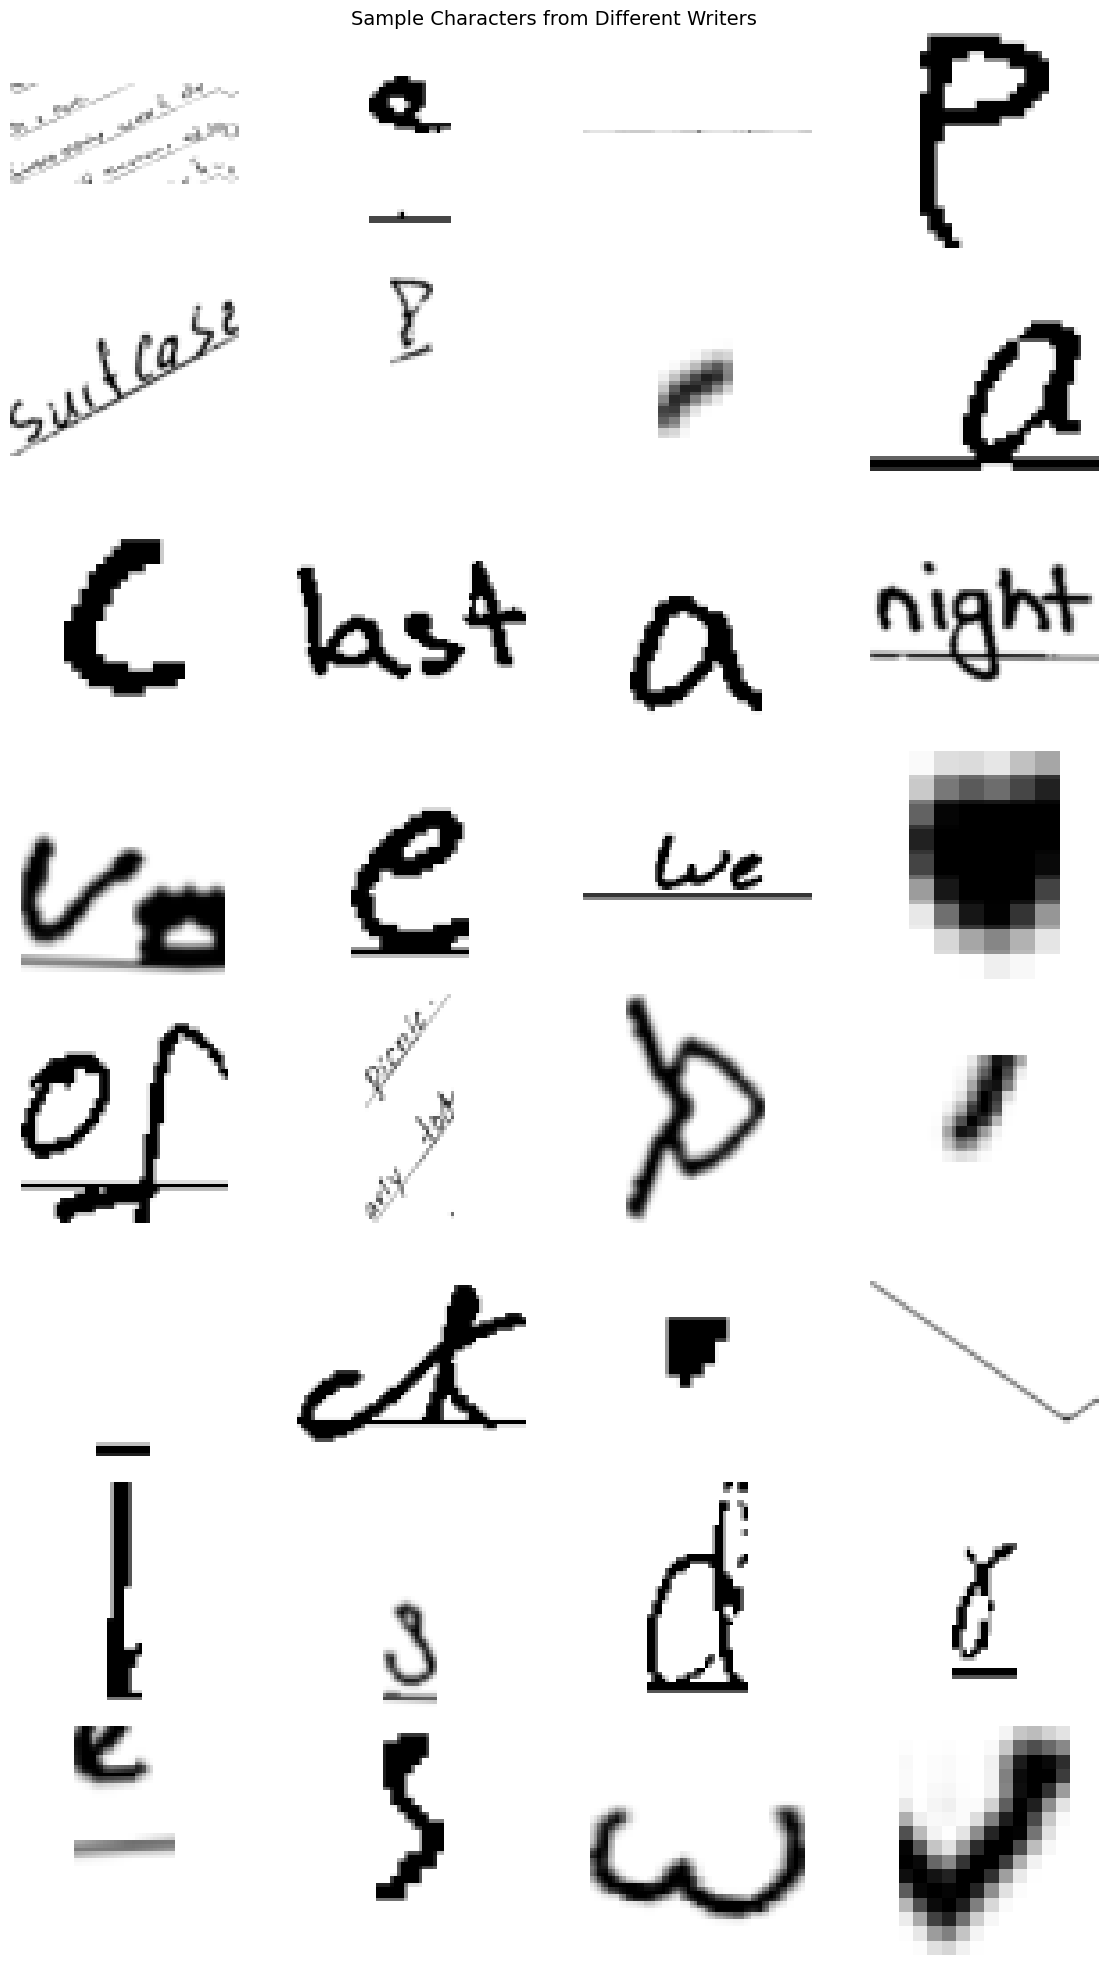


Note: Each writer has a unique character formation style.


In [33]:
# =============================================================================
# CELL 14: Visualize Sample Characters
# =============================================================================

print("SAMPLE CHARACTERS FROM DIFFERENT WRITERS")
print("=" * 60)

# Show 4 characters from 8 different writers
fig, axes = plt.subplots(8, 4, figsize=(12, 20))

unique_labels = label_encoder.classes_[:8]

for row, writer_label in enumerate(unique_labels):
    # Get indices for this writer
    writer_idx = label_encoder.transform([writer_label])[0]
    char_indices = np.where(y_train == writer_idx)[0]
    
    # Show 4 random characters
    sample_indices = np.random.choice(char_indices, min(4, len(char_indices)), replace=False)
    
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(X_train[idx])
        if col == 0:
            axes[row, col].set_ylabel(f"Writer {writer_label}", fontsize=10)
        axes[row, col].axis('off')

plt.suptitle("Sample Characters from Different Writers", fontsize=14)
plt.tight_layout()
plt.show()

print("\nNote: Each writer has a unique character formation style.")

In [34]:
# =============================================================================
# CELL 15: Shuffle Training Data
# =============================================================================

print("SHUFFLING TRAINING DATA")
print("=" * 60)

# Shuffle training data
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

print(f"Training data shuffled: {len(X_train)} samples")

# Verify distribution after shuffle
print(f"\nLabel distribution after shuffle (first 1000 samples):")
sample_labels = y_train[:1000]
unique, counts = np.unique(sample_labels, return_counts=True)
print(f"  Unique labels: {len(unique)}")
print(f"  Distribution looks uniform: {np.std(counts) < np.mean(counts) * 0.5}")

SHUFFLING TRAINING DATA
Training data shuffled: 37885 samples

Label distribution after shuffle (first 1000 samples):
  Unique labels: 70
  Distribution looks uniform: True


In [35]:
# =============================================================================
# CELL 16: Calculate Class Weights
# =============================================================================

print("CALCULATING CLASS WEIGHTS")
print("=" * 60)

# Calculate class weights for imbalanced classes
# Some writers may produce more extractable characters
label_counts = Counter(y_train.tolist())
total_samples = len(y_train)
n_classes = len(label_counts)

class_weights = {}
for label_idx, count in label_counts.items():
    # Formula: total / (n_classes * count_for_class)
    class_weights[label_idx] = total_samples / (n_classes * count)

# Show weight distribution
weights = list(class_weights.values())
print(f"Class weights computed for {n_classes} classes:")
print(f"  Min weight: {min(weights):.4f}")
print(f"  Max weight: {max(weights):.4f}")
print(f"  Mean weight: {np.mean(weights):.4f}")

print("\nClass weights will be used during training to balance the loss.")

CALCULATING CLASS WEIGHTS
Class weights computed for 70 classes:
  Min weight: 0.5626
  Max weight: 4.0090
  Mean weight: 1.1571

Class weights will be used during training to balance the loss.


In [36]:
# =============================================================================
# CELL 17: Save Preprocessed Data
# =============================================================================

print("SAVING PREPROCESSED DATA")
print("=" * 60)

# Save numpy arrays
np.save(os.path.join(PREPROCESSED_DIR, 'X_train_chars.npy'), X_train)
np.save(os.path.join(PREPROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PREPROCESSED_DIR, 'X_test_chars.npy'), X_test)
np.save(os.path.join(PREPROCESSED_DIR, 'y_test.npy'), y_test)

print(f"✓ X_train_chars.npy: {X_train.shape}")
print(f"✓ y_train.npy: {y_train.shape}")
print(f"✓ X_test_chars.npy: {X_test.shape}")
print(f"✓ y_test.npy: {y_test.shape}")

# Save label encoder
with open(os.path.join(PREPROCESSED_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"✓ label_encoder.pkl")

# Save test character map (for aggregation during evaluation)
with open(os.path.join(PREPROCESSED_DIR, 'test_char_map.pkl'), 'wb') as f:
    pickle.dump(test_char_map, f)
print(f"✓ test_char_map.pkl")

# Save test filenames
with open(os.path.join(PREPROCESSED_DIR, 'test_filenames.pkl'), 'wb') as f:
    pickle.dump(test_filenames, f)
print(f"✓ test_filenames.pkl")

# Save class weights
with open(os.path.join(PREPROCESSED_DIR, 'class_weights.pkl'), 'wb') as f:
    pickle.dump(class_weights, f)
print(f"✓ class_weights.pkl")

# Save configuration
config = {
    'CHAR_H': CHAR_H,
    'CHAR_W': CHAR_W,
    'NUM_CHANNELS': NUM_CHANNELS,
    'NUM_CLASSES': NUM_CLASSES,
    'MIN_CHAR_WIDTH': MIN_CHAR_WIDTH,
    'NUM_VERTICAL_SPLITS': NUM_VERTICAL_SPLITS,
    'AUGMENT_EACH_SPLIT': AUGMENT_EACH_SPLIT,
    'RANDOM_SEED': RANDOM_SEED,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'test_images': len(test_filenames),
}

with open(os.path.join(PREPROCESSED_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(config, f)

# Also save as JSON for easy viewing
with open(os.path.join(PREPROCESSED_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ config.pkl / config.json")

# Save labels as JSON (for run.py)
labels_list = label_encoder.classes_.tolist()
with open(os.path.join(PREPROCESSED_DIR, 'labels.json'), 'w') as f:
    json.dump(labels_list, f, indent=2)
print(f"✓ labels.json")

SAVING PREPROCESSED DATA
✓ X_train_chars.npy: (37885, 64, 64, 3)
✓ y_train.npy: (37885,)
✓ X_test_chars.npy: (14615, 64, 64, 3)
✓ y_test.npy: (14615,)
✓ label_encoder.pkl
✓ test_char_map.pkl
✓ test_filenames.pkl
✓ class_weights.pkl
✓ config.pkl / config.json
✓ labels.json


In [37]:
# =============================================================================
# CELL 18: Final Summary
# =============================================================================

print("="*60)
print("DATA PREPROCESSING COMPLETE - CHARACTER-BASED APPROACH")
print("="*60)
print("\n📊 DATASET STATISTICS:")
print(f"   Training images: {len(train_files)}")
print(f"   Test images: {len(test_files)}")
print(f"   Writers (classes): {NUM_CLASSES}")
print(f"\n📝 CHARACTER EXTRACTION:")
print(f"   Training characters: {len(X_train):,}")
print(f"   Test characters: {len(X_test):,}")
print(f"   Character size: {CHAR_H}×{CHAR_W}×{NUM_CHANNELS}")
print(f"\n📁 OUTPUT FILES (in {os.path.basename(PREPROCESSED_DIR)}/):")
print(f"   ✓ X_train_chars.npy, y_train.npy")
print(f"   ✓ X_test_chars.npy, y_test.npy")
print(f"   ✓ label_encoder.pkl, class_weights.pkl")
print(f"   ✓ test_char_map.pkl, test_filenames.pkl")
print(f"   ✓ config.pkl, config.json, labels.json")
print(f"\n✅ Ready for model training!")
print(f"   Next: Run model_training.ipynb")

DATA PREPROCESSING COMPLETE - CHARACTER-BASED APPROACH

📊 DATASET STATISTICS:
   Training images: 70
   Test images: 140
   Writers (classes): 70

📝 CHARACTER EXTRACTION:
   Training characters: 37,885
   Test characters: 14,615
   Character size: 64×64×3

📁 OUTPUT FILES (in preprocessed/):
   ✓ X_train_chars.npy, y_train.npy
   ✓ X_test_chars.npy, y_test.npy
   ✓ label_encoder.pkl, class_weights.pkl
   ✓ test_char_map.pkl, test_filenames.pkl
   ✓ config.pkl, config.json, labels.json

✅ Ready for model training!
   Next: Run model_training.ipynb
